## Import Libraries

In [173]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping
from keras import regularizers

### Load Data 

In [10]:
df = pd.read_csv("Crop_recommendation.csv")

## Preprocessing

### First Five rows

In [4]:
dataset.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


### Last Five rows

In [101]:
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


### Shape 

In [102]:
df.shape

(2200, 8)

### Information of Dataset

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


### Check Null values

In [104]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

### Check Duplicate Values

In [105]:
df.duplicated().sum()

np.int64(0)

In [106]:
df['label'].value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

### Summary

In [107]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


## EDA

In [108]:
num_col = df.select_dtypes(exclude = 'object').columns

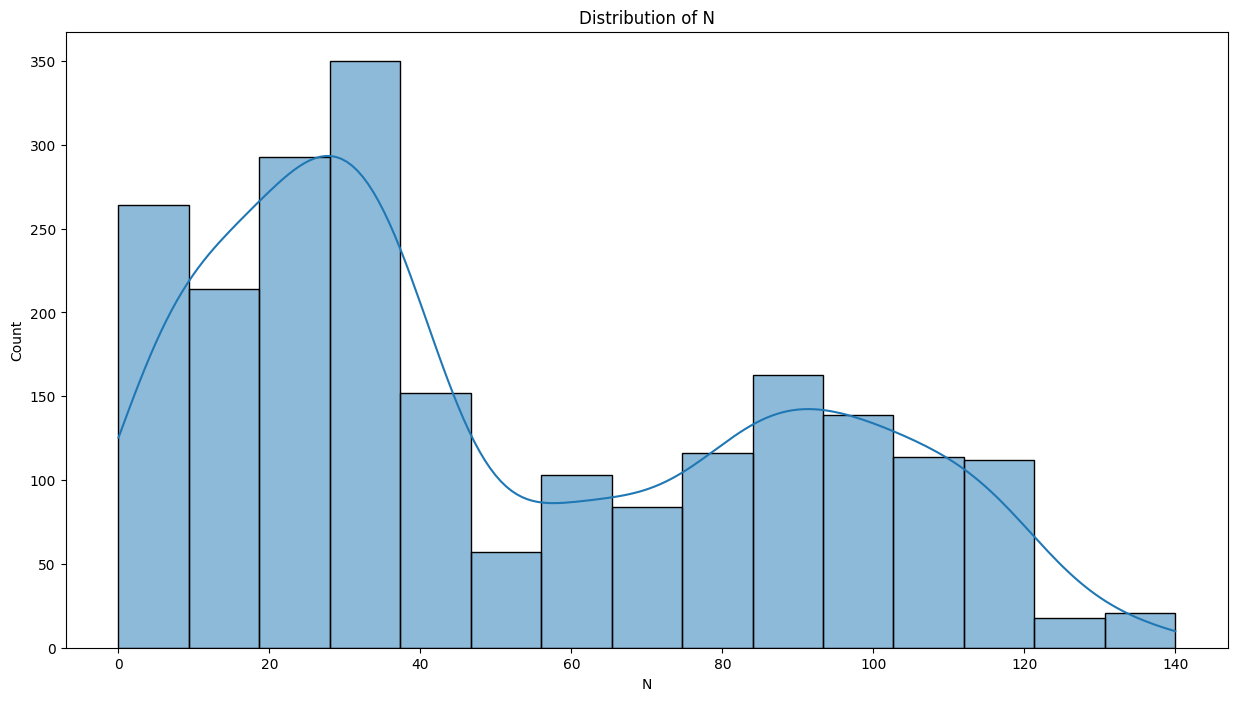

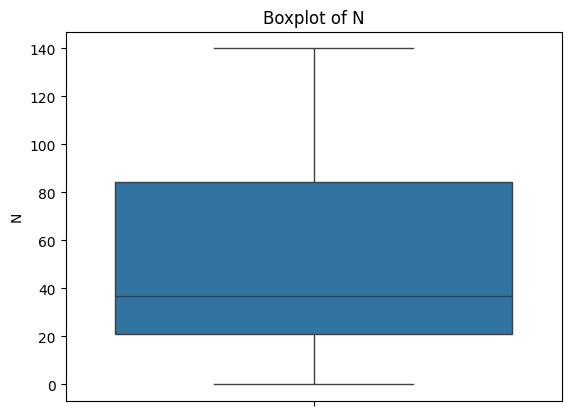

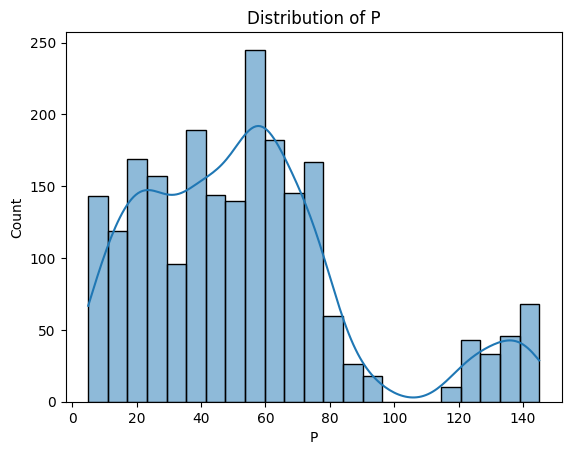

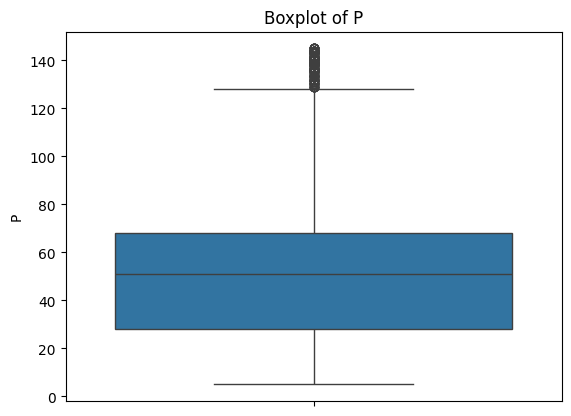

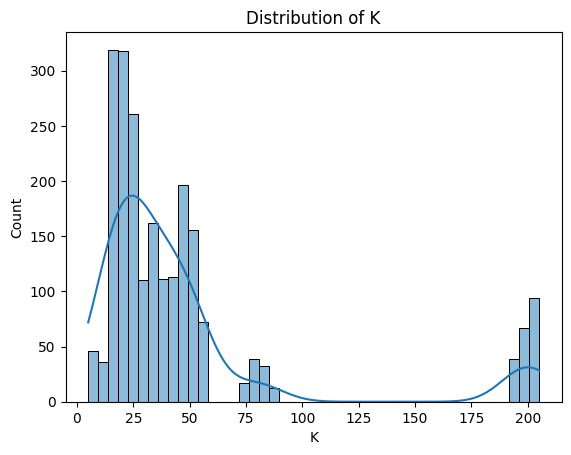

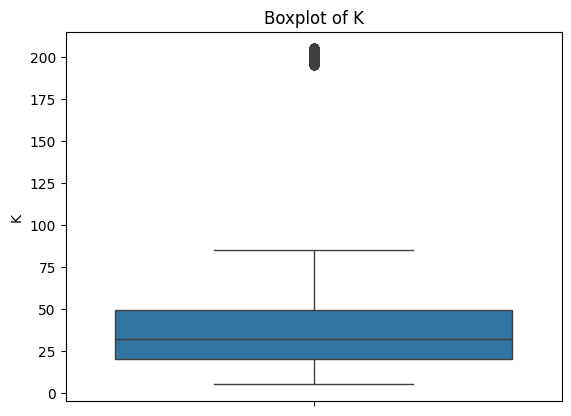

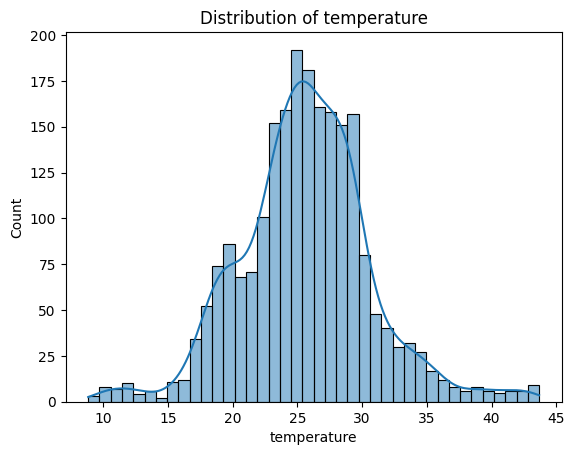

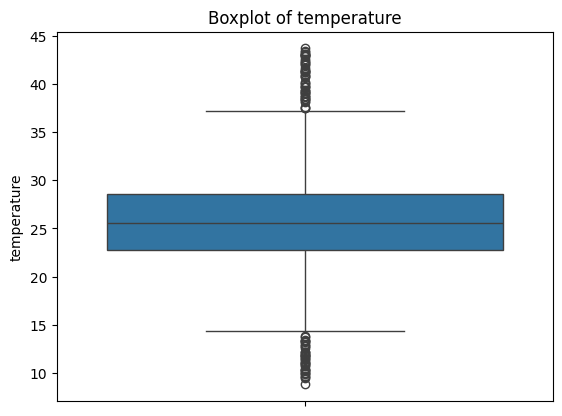

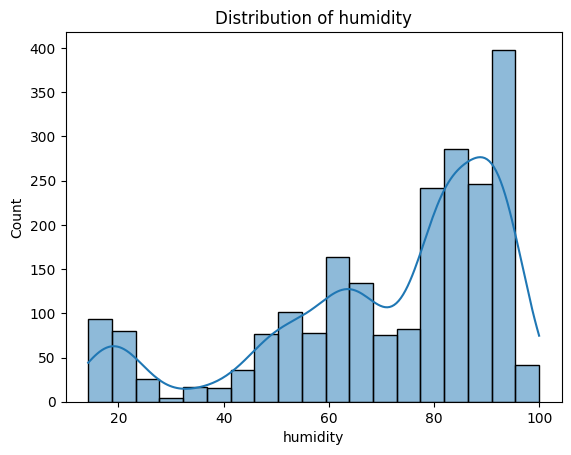

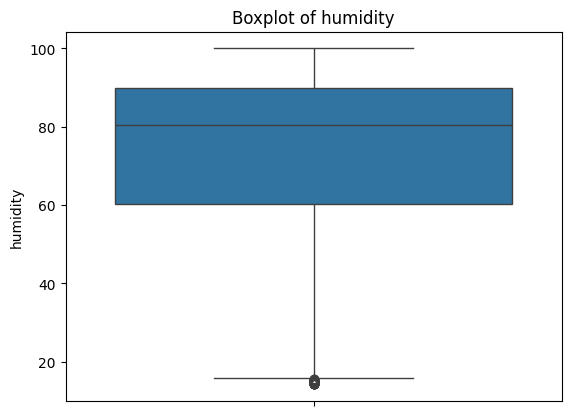

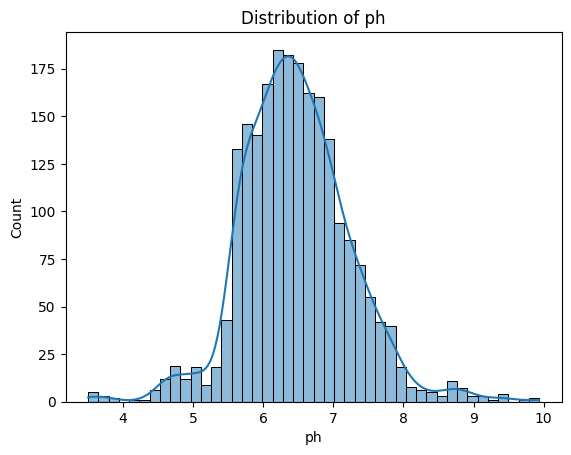

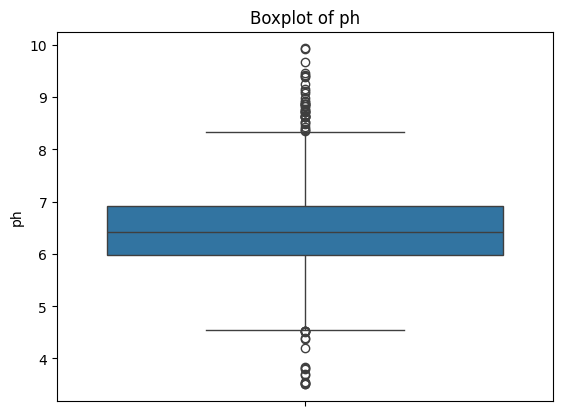

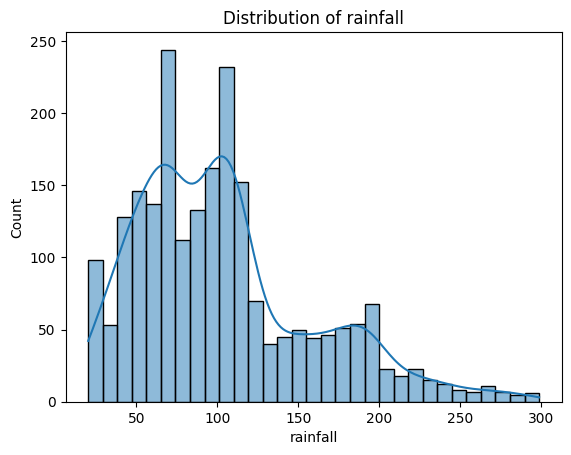

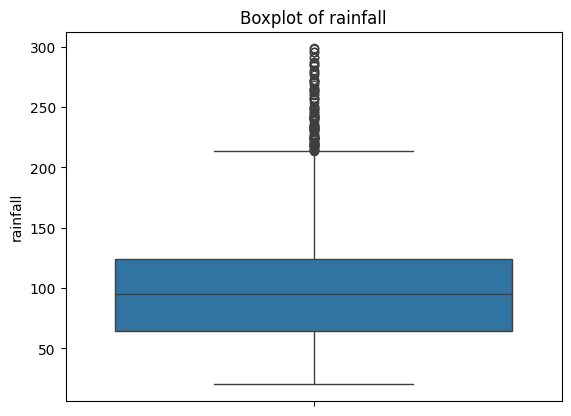

In [109]:
plt.figure(figsize = (15,8))

for col in num_col:
    sns.histplot(df[col], kde = True)
    plt.title(f'Distribution of {col}')
    plt.show()

    sns.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### Separate Target and Features

In [110]:
X = df.drop('label', axis=1)
y = df['label']

### Label Encoder

In [111]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

### Standard Scaler

In [112]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

### Separate Training and Testing Data

In [113]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### Build ANN

In [162]:
ann = Sequential()

In [163]:
ann.add(Dense(units=128,activation='relu',input_dim=7))
ann.add(Dropout(0.3))
ann.add(Dense(units = 64, activation = 'relu'))
ann.add(Dropout(0.3))
ann.add(Dense(units = 22, activation = 'softmax'))

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [164]:
ann.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

#### Early Stoping

In [165]:
callback = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True,
    verbose = 1)

In [166]:
history = ann.fit(X_train,y_train,validation_split=0.2,epochs=100,batch_size=32, callbacks = callback)

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.1825 - loss: 2.8352 - val_accuracy: 0.4744 - val_loss: 2.4514
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4389 - loss: 2.1823 - val_accuracy: 0.7131 - val_loss: 1.6931
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5888 - loss: 1.4927 - val_accuracy: 0.7898 - val_loss: 1.0488
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6662 - loss: 1.1066 - val_accuracy: 0.8409 - val_loss: 0.7368
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7301 - loss: 0.8504 - val_accuracy: 0.8693 - val_loss: 0.5514
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7521 - loss: 0.7264 - val_accuracy: 0.8892 - val_loss: 0.4653
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7990 - loss: 0.6189 - val_accuracy: 0.9006 - val_loss: 0.3854
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8175 - loss: 0.5573 - val_accuracy: 0.9034 - 

### Evaluation

In [167]:
loss, accuracy = ann.evaluate(X_test, y_test)
print("Accuracy:", accuracy)
print("Loss:", loss)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9614 - loss: 0.0908
Accuracy: 0.9613636136054993
Loss: 0.09080726653337479


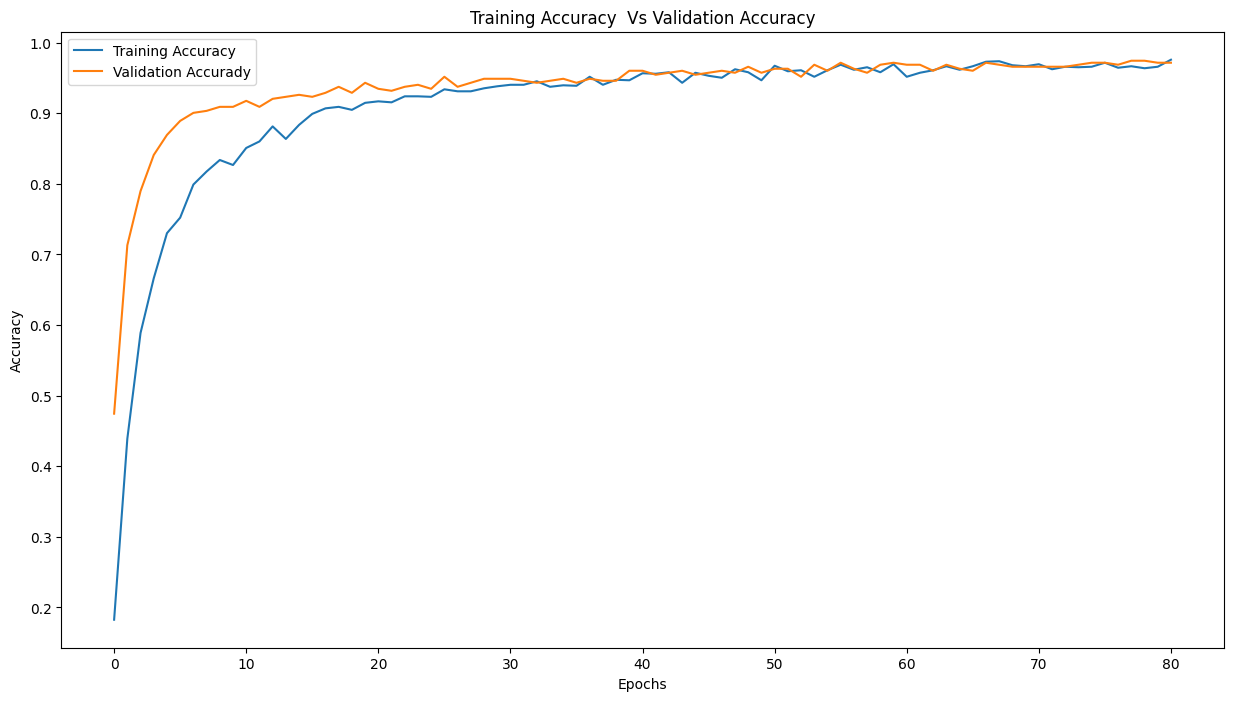

In [168]:
plt.figure(figsize = (15,8))

plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accurady')
plt.title('Training Accuracy  Vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

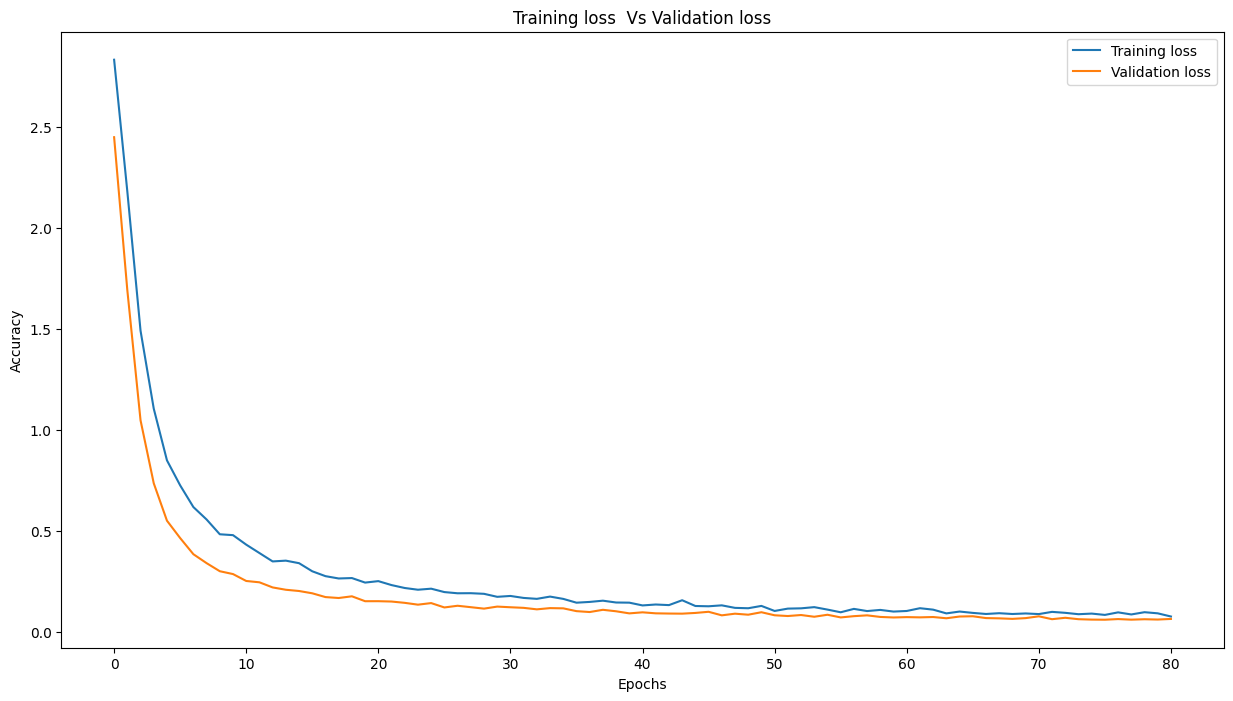

In [169]:
plt.figure(figsize = (15,8))

plt.plot(history.history['loss'], label = 'Training loss')
plt.plot(history.history['val_loss'], label = 'Validation loss')
plt.title('Training loss  Vs Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Check on sample 

In [170]:
sample = [[90,42,43,20.8,82,6.5,202]]

sample = scaler.transform(sample)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [171]:
prediction = ann.predict(sample)
predicted_crop = encoder.inverse_transform(
    [np.argmax(prediction)]
)

print(predicted_crop)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
['rice']


### Save Model

In [172]:
ann.save("crop_recommendation_model.keras")

In [174]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [175]:
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)